In [27]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler

In [28]:
#Affichage des premières lignes
df_origine = pd.read_csv('data/online_shoppers_intention.csv')
df= df_origine.copy()

print(df.head())

   Administrative  Administrative_Duration  Informational  \
0               0                      0.0              0   
1               0                      0.0              0   
2               0                      0.0              0   
3               0                      0.0              0   
4               0                      0.0              0   

   Informational_Duration  ProductRelated  ProductRelated_Duration  \
0                     0.0               1                 0.000000   
1                     0.0               2                64.000000   
2                     0.0               1                 0.000000   
3                     0.0               2                 2.666667   
4                     0.0              10               627.500000   

   BounceRates  ExitRates  PageValues  SpecialDay Month  OperatingSystems  \
0         0.20       0.20         0.0         0.0   Feb                 1   
1         0.00       0.10         0.0         0.0   Feb   

In [29]:
#Vérification des dimensions (Lignes, Colonnes)
print(df.shape)

(12330, 18)


Notre data_set est de 18 features et 12330 enregistrement

In [30]:
 #Inspection des types de colonnes et des valeurs manquantes
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

L'absence de valeurs nulles, pas naicessaire de les traiter.


In [31]:
print(df.describe())

       Administrative  Administrative_Duration  Informational  \
count    12330.000000             12330.000000   12330.000000   
mean         2.315166                80.818611       0.503569   
std          3.321784               176.779107       1.270156   
min          0.000000                 0.000000       0.000000   
25%          0.000000                 0.000000       0.000000   
50%          1.000000                 7.500000       0.000000   
75%          4.000000                93.256250       0.000000   
max         27.000000              3398.750000      24.000000   

       Informational_Duration  ProductRelated  ProductRelated_Duration  \
count            12330.000000    12330.000000             12330.000000   
mean                34.472398       31.731468              1194.746220   
std                140.749294       44.475503              1913.669288   
min                  0.000000        0.000000                 0.000000   
25%                  0.000000        7.00000

Les données sont complètes mais très asymétriques. L'activité se focalise sur les produits, avec de nombreux outliers (valeurs extrêmes). Cela rend la normalisation obligatoire.


In [32]:
# Compter les doublons
nb_doublons = df.duplicated().sum()
print(f"Nombre de lignes dupliquées détectées : {nb_doublons}")

# Supprimer les doublons (si nécessaire)
if nb_doublons > 0:
    df = df.drop_duplicates()
    print("Doublons supprimés.")

Nombre de lignes dupliquées détectées : 125
Doublons supprimés.


In [33]:
# Vérifier les valeurs uniques des colonnes catégorielles
categorical_features = ['Month','VisitorType','OperatingSystems', 'Browser', 'Region', 'TrafficType']

for col in categorical_features:
    print(f"\nValeurs uniques pour {col} :")
    print(np.sort(df[col].unique()))


Valeurs uniques pour Month :
['Aug' 'Dec' 'Feb' 'Jul' 'June' 'Mar' 'May' 'Nov' 'Oct' 'Sep']

Valeurs uniques pour VisitorType :
['New_Visitor' 'Other' 'Returning_Visitor']

Valeurs uniques pour OperatingSystems :
[1 2 3 4 5 6 7 8]

Valeurs uniques pour Browser :
[ 1  2  3  4  5  6  7  8  9 10 11 12 13]

Valeurs uniques pour Region :
[1 2 3 4 5 6 7 8 9]

Valeurs uniques pour TrafficType :
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]


L'analyse des valeurs uniques montre un dataset cohérent
On remarque que la variable Month couvre 10 mois (janvier et avril sont absents)
les autres vars sont déjà dons la forme numerique

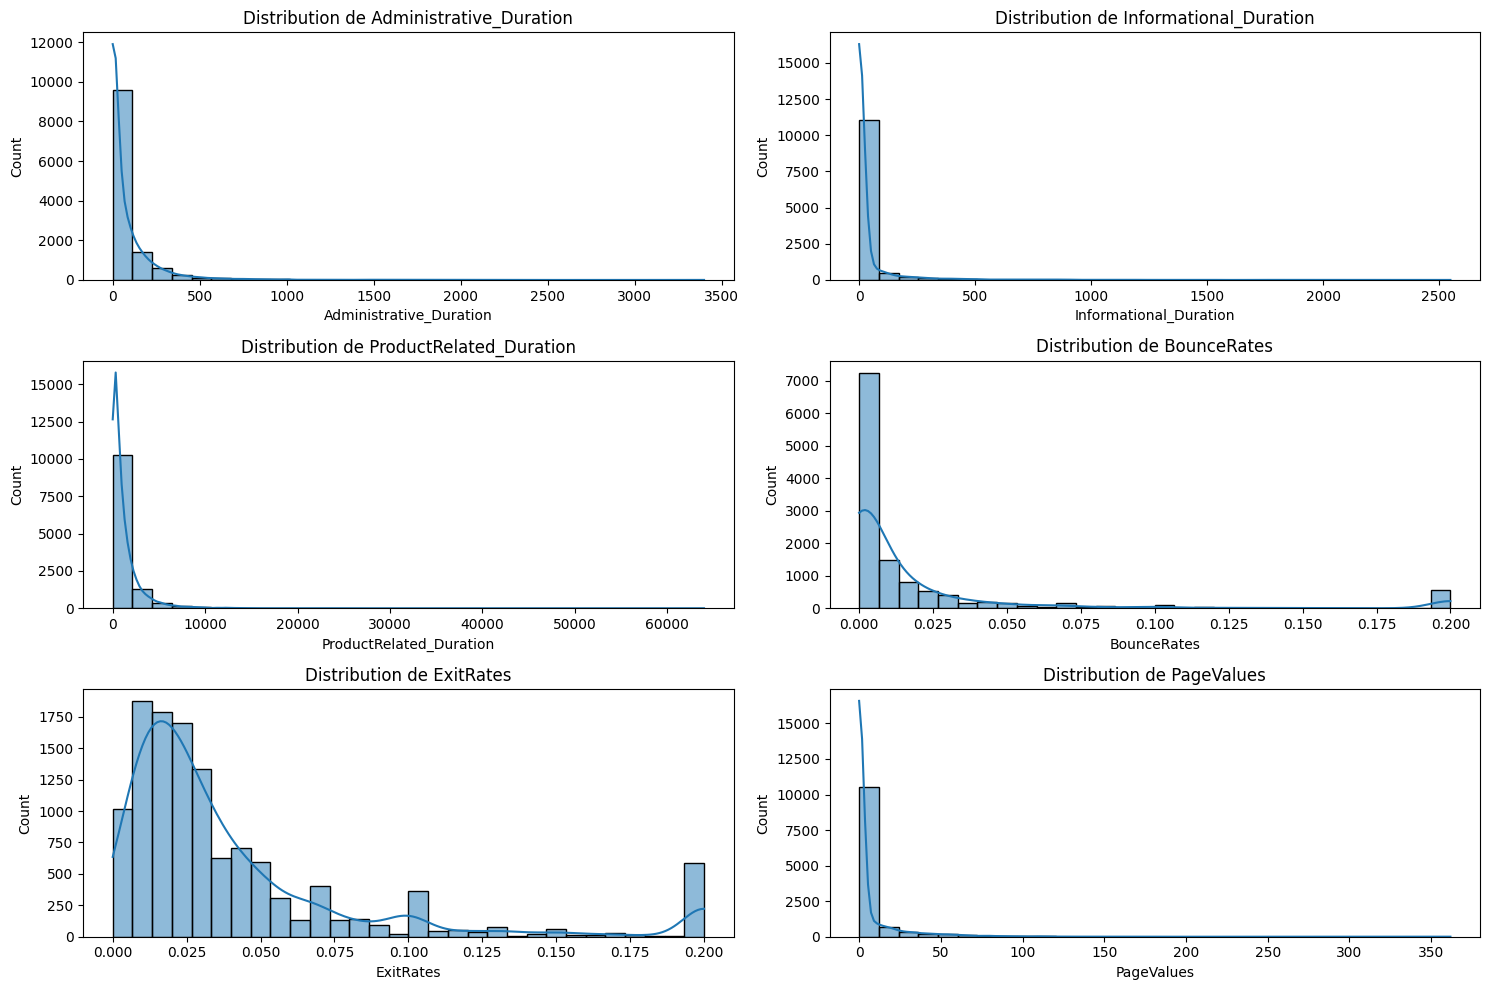

In [34]:
# Les cols numeriques
num_cols = ['Administrative_Duration', 'Informational_Duration', 'ProductRelated_Duration',
            'BounceRates', 'ExitRates', 'PageValues']

# Visualisation par histogrammes
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols):
    plt.subplot(3, 2, i+1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution de {col}')
plt.tight_layout()
plt.show()


Comme vu précédemment, la moyenne est souvent bien plus élevée que la médiane , ce qui confirme une asymétrie positive.

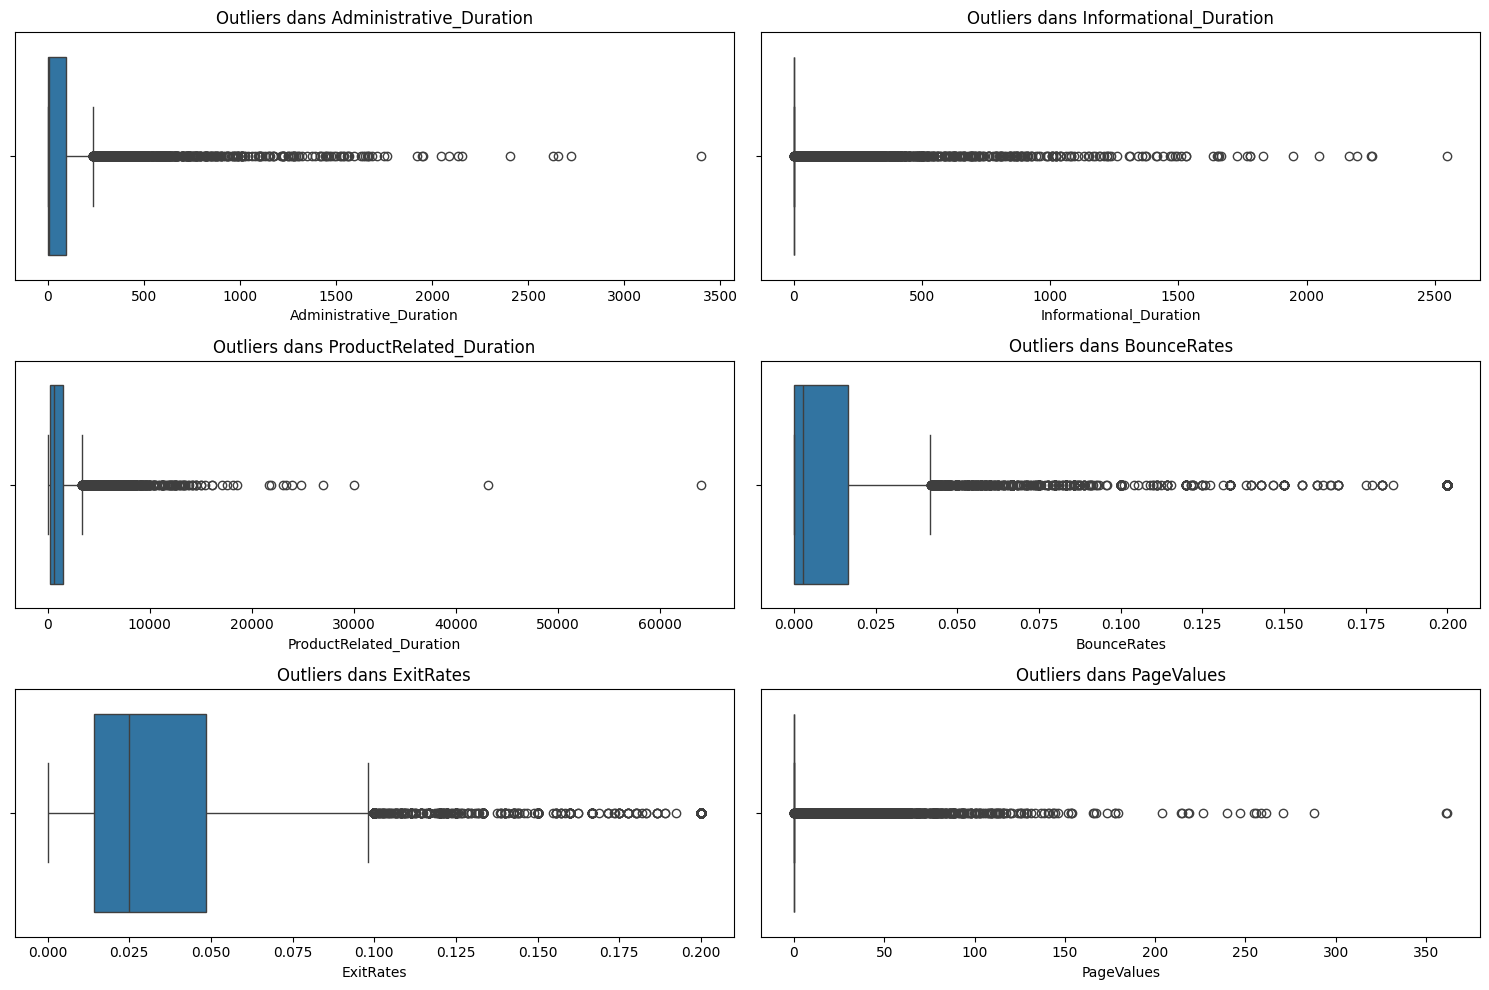

In [35]:
# Visualisation par Boxplots (pour les Outliers)
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols):
    plt.subplot(3, 2, i+1)
    sns.boxplot(x=df[col])
    plt.title(f'Outliers dans {col}')
plt.tight_layout()
plt.show()

Les boxplots montreront de nombreux points au-delà des moustaches, confirmant la présence d'utilisateurs "atypiques" restant très longtemps sur le site.

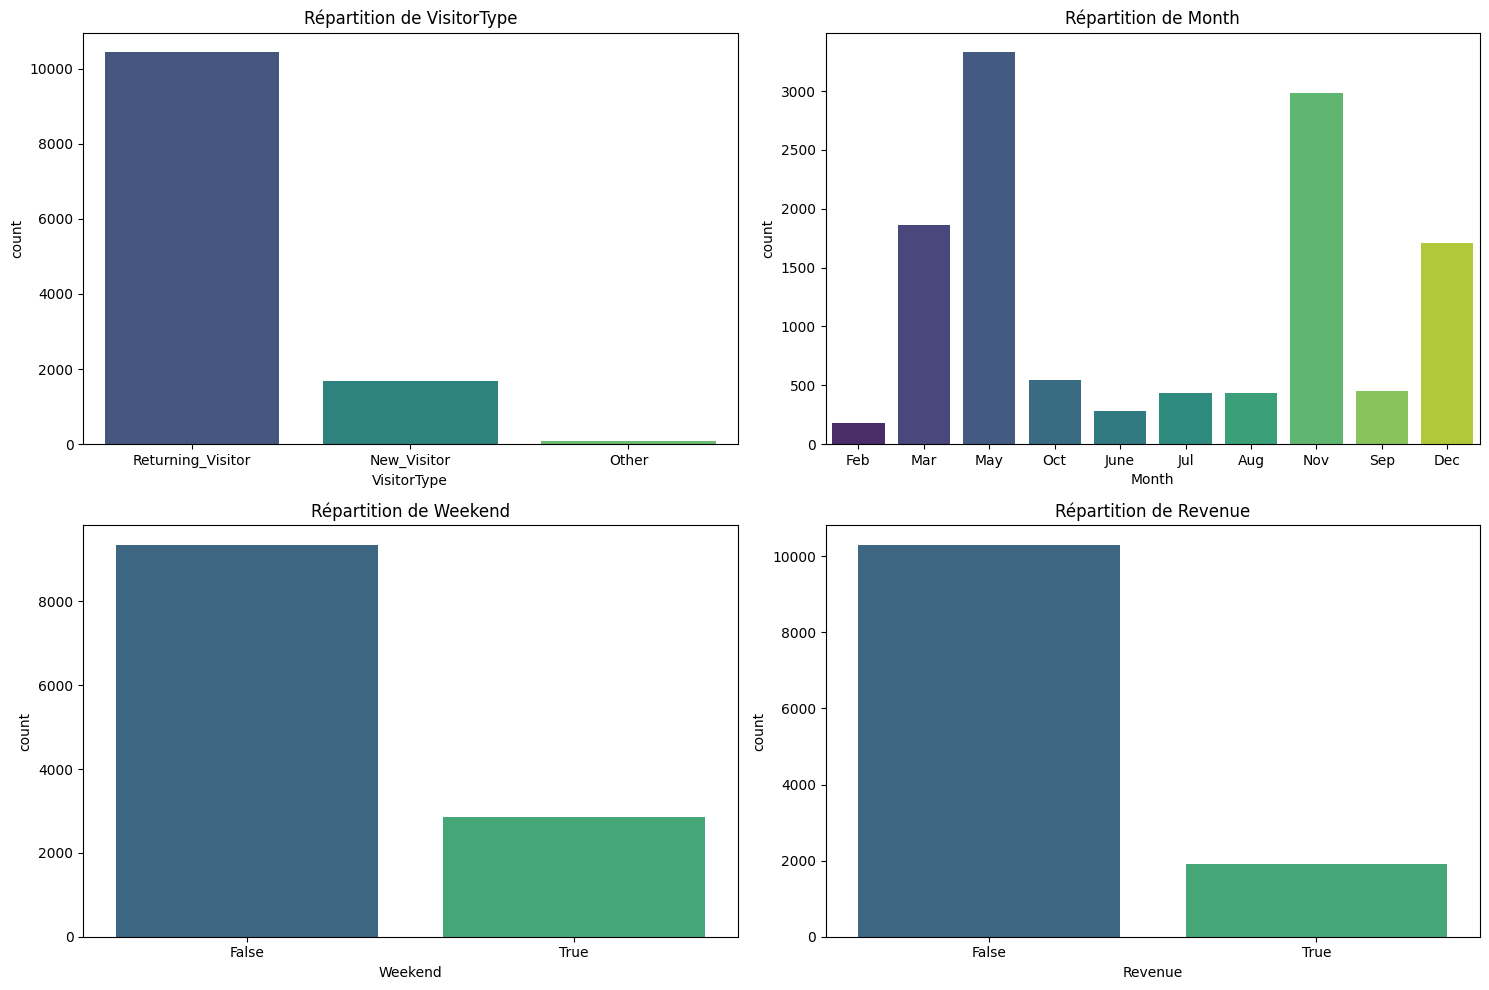

In [36]:
cat_cols = ['VisitorType', 'Month', 'Weekend', 'Revenue']

plt.figure(figsize=(15, 10))
for i, col in enumerate(cat_cols):
    plt.subplot(2, 2, i+1)
    # Calcul des pourcentages pour plus de clarté
    ax = sns.countplot(data=df, x=col, hue=col, palette='viridis', legend=False)
    plt.title(f'Répartition de {col}')
    """
    # Ajout des étiquettes de pourcentage sur les barres
    total = len(df[col])
    for p in ax.patches:
        percentage = f'{100 * p.get_height() / total:.1f}%'
        ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='baseline', fontsize=12, color='black', xytext=(0, 5),
                    textcoords='offset points')
    """


plt.tight_layout()
plt.show()

La grande majorité des utilisateurs sont des Returning Visitors (visiteurs récurrents).
Month : Mai et Novembre sont généralement les mois les plus actifs dans ce dataset. Janvier et Avril sont totalement absents des données.
La plupart des sessions ont lieu en semaine (environ 75-80%).
Revenue (Cible) : Vous confirmerez ici le déséquilibre de classe. Environ 85% des sessions ne génèrent pas de vente (False), contre seulement 15% de succès (True).

Résumé de l'analyse :
Vos données sont dominées par des visiteurs fidèles naviguant en semaine, principalement durant quelques mois clés, avec une immense majorité de sessions sans achat. Cette structure impose d'être vigilant sur le choix des modèles pour ne pas ignorer la classe minoritaire (les acheteurs).

Pour la cible

Dans un dataset aussi déséquilibré, la précision simple (accuracy) est trompeuse.
Exemple : Si vous créez un modèle "idiot" qui prédit systématiquement False, il aura une précision de 85 %. Pourtant, il sera totalement inutile car il ne détectera aucun acheteur.

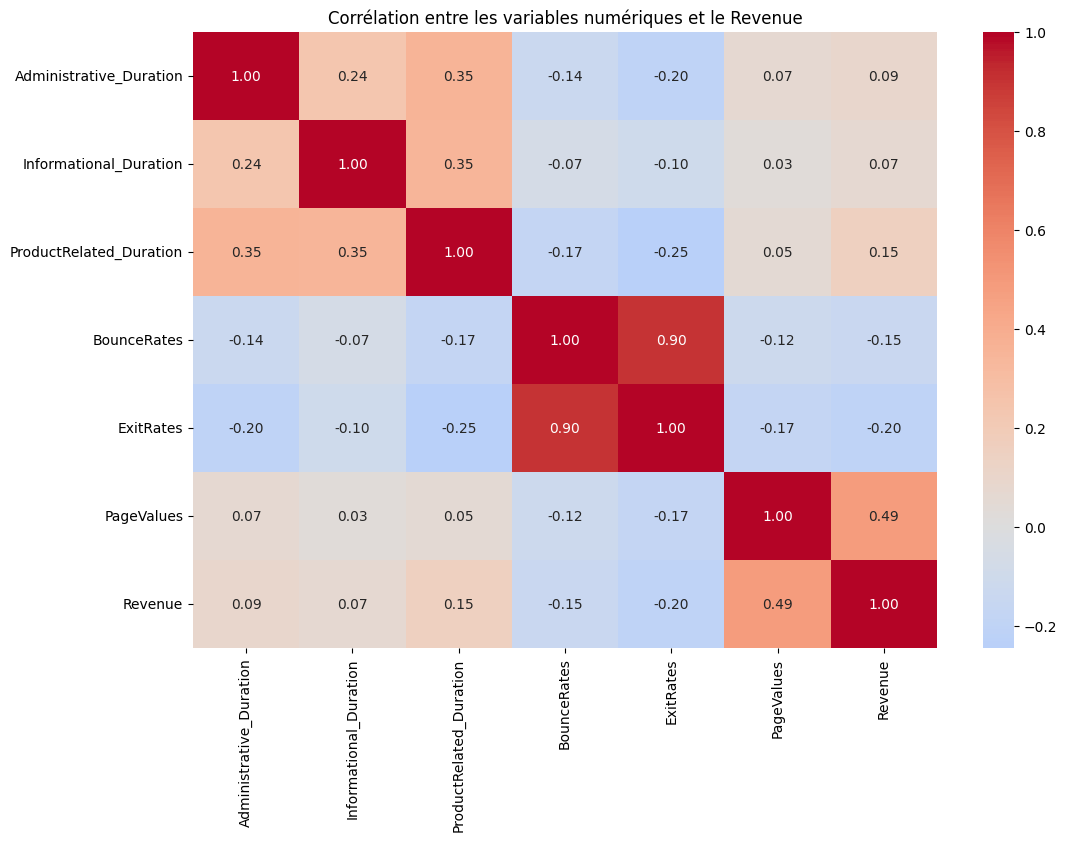

In [37]:
# Calcul de la matrice de corrélation
plt.figure(figsize=(12, 8))
correlation_matrix = df[num_cols + ['Revenue']].corr()

# Affichage de la Heatmap
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Corrélation entre les variables numériques et le Revenue')
plt.show()

Une corrélation très forte entre **PageValues** et Revenue, confirmant que cette métrique de Google Analytics est le meilleur indicateur de vente.

**ExitRates** (-0.20) et **BounceRates** (-0.15) plus le taux de rebond ou de sortie est élevé, moins l'utilisateur a de chances de finaliser une transaction.

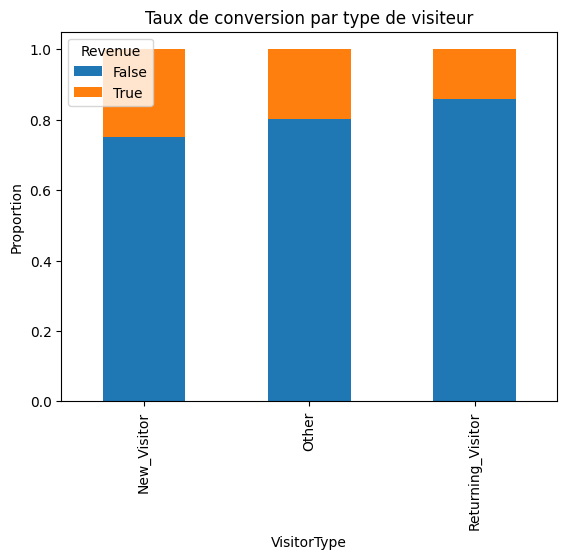

In [38]:
# Relation entre VisitorType et Revenue
pd.crosstab(df['VisitorType'], df['Revenue'], normalize='index').plot(kind='bar', stacked=True)
plt.title('Taux de conversion par type de visiteur')
plt.ylabel('Proportion')
plt.show()

* **En volume absolu** : Ce sont les Returning Visitors (visiteurs récurrents). Comme ils représentent la grande majorité du trafic sur le site, c'est ce groupe qui génère mathématiquement le plus gros du chiffre d'affaires total.

* **En taux de conversion** (Efficacité) : Ce sont les New Visitors (nouveaux visiteurs). Proportionnellement à leur nombre, ils achètent beaucoup plus souvent que les autres.

In [39]:
# 1. Initialisation de l'encodeur
# handle_unknown='ignore' est utile pour ne pas planter si une nouvelle catégorie apparaît plus tard
enc = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='error')

# 2. Sélection des colonnes à encoder
cat_cols = ['Month', 'VisitorType']

# 3. Fit et Transform
# On transforme les colonnes et on récupère un tableau NumPy
X_enc = enc.fit_transform(df[cat_cols])

# 4. Création d'un DataFrame avec les nouveaux noms de colonnes
df_enc = pd.DataFrame(X_enc, columns=enc.get_feature_names_out(cat_cols), index=df.index)

# 5. Fusion avec le dataset principal et suppression des anciennes colonnes
df_final = pd.concat([df.drop(cat_cols, axis=1), df_enc], axis=1)

# S'assurer que les autres colonnes binaires sont bien en int
df_final['Weekend'] = df_final['Weekend'].astype(int)
df_final['Revenue'] = df_final['Revenue'].astype(int)

print(df_final.head())

   Administrative  Administrative_Duration  Informational  \
0               0                      0.0              0   
1               0                      0.0              0   
2               0                      0.0              0   
3               0                      0.0              0   
4               0                      0.0              0   

   Informational_Duration  ProductRelated  ProductRelated_Duration  \
0                     0.0               1                 0.000000   
1                     0.0               2                64.000000   
2                     0.0               1                 0.000000   
3                     0.0               2                 2.666667   
4                     0.0              10               627.500000   

   BounceRates  ExitRates  PageValues  SpecialDay  ...  Month_Feb  Month_Jul  \
0         0.20       0.20         0.0         0.0  ...        1.0        0.0   
1         0.00       0.10         0.0         0.0  .

Dataset est désormais un tableau purement numérique, prêt à être traité par n'importe quel algorithme de Machine Learning sans erreur d'interprétation.

In [40]:
# 1. Initialisation du scaler pour l'intervalle [0, 1]
min_max_scaler = MinMaxScaler()

# 2. Liste de vos colonnes numériques
num_cols = ['Administrative_Duration', 'Informational_Duration', 'ProductRelated_Duration',
            'BounceRates', 'ExitRates', 'PageValues']

# 3. Application de la transformation
df_final[num_cols] = min_max_scaler.fit_transform(df_final[num_cols])

# Vérification : le min doit être 0 et le max doit être 1
print(df_final[num_cols].describe().loc[['min', 'max']])

     Administrative_Duration  Informational_Duration  ProductRelated_Duration  \
min                      0.0                     0.0                      0.0   
max                      1.0                     1.0                      1.0   

     BounceRates  ExitRates  PageValues  
min          0.0        0.0         0.0  
max          1.0        1.0         1.0  


La standarisation min-max pour rendre tous vals entre 0 et 1

pourQuoi non z-score : c'est parceque on veux applique l'une des methodes de normalisation et les vals doivent etre positifs

In [41]:
# Liste des colonnes très asymétriques
cols_to_log = ['Administrative_Duration', 'Informational_Duration', 'ProductRelated_Duration', 'PageValues']

# Application de log(x + 1)
df_final[cols_to_log] = np.log1p(df_final[cols_to_log])

# Vérification
print(df_final[cols_to_log].head())

   Administrative_Duration  Informational_Duration  ProductRelated_Duration  \
0                      0.0                     0.0                 0.000000   
1                      0.0                     0.0                 0.001000   
2                      0.0                     0.0                 0.000000   
3                      0.0                     0.0                 0.000042   
4                      0.0                     0.0                 0.009761   

   PageValues  
0         0.0  
1         0.0  
2         0.0  
3         0.0  
4         0.0  


Comme vous l'avez vu dans vos analyses précédentes, vos données de navigation ne sont pas réparties uniformément. En appliquant le log

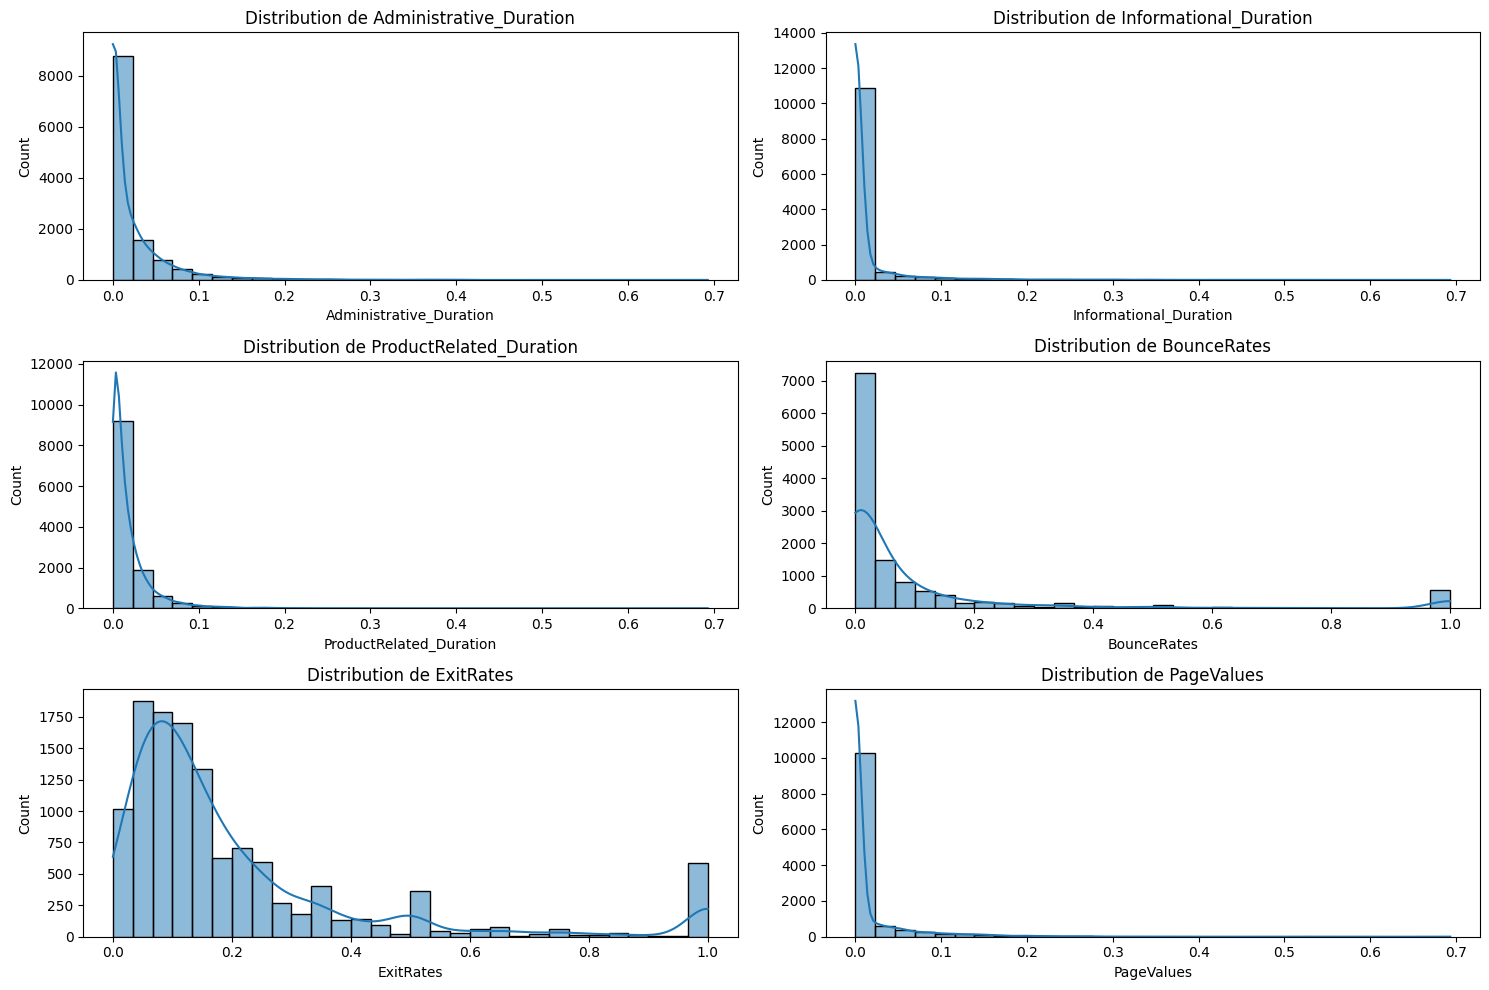

In [42]:
# Les cols numeriques
num_cols = ['Administrative_Duration', 'Informational_Duration', 'ProductRelated_Duration',
            'BounceRates', 'ExitRates', 'PageValues']

# Visualisation par histogrammes
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols):
    plt.subplot(3, 2, i+1)
    sns.histplot(df_final[col], kde=True, bins=30)
    plt.title(f'Distribution de {col}')
plt.tight_layout()
plt.show()

**Administrative, Informational, ProductRelated_Duration et PageValues** : On observe un pic immense à $0$ et une "longue traîne" vers la droite.

**BounceRates et ExitRates** : Bien que plus étalées, elles sont également concentrées sur les petites valeurs avec des pics isolés à l'extrémité droite ($0.20$), ce qui indique des outliers spécifiques.

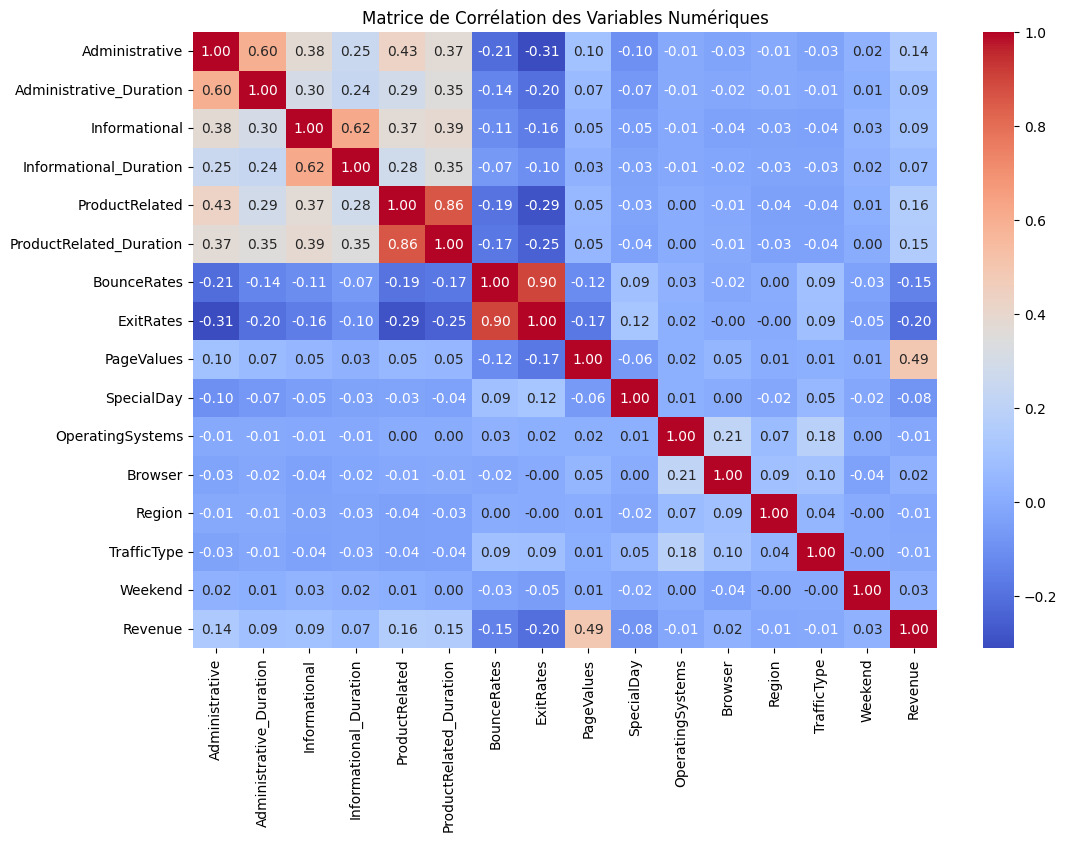

In [43]:
# Matrice de corrélation pour les variables numériques
plt.figure(figsize=(12, 8))
# On ne garde que les colonnes numériques pour la corrélation
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title("Matrice de Corrélation des Variables Numériques")
plt.show()

C:\Users\aliin\AppData\Local\Temp\ipykernel_6952\2642825172.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Revenue', y='PageValues', data=df, palette='viridis')


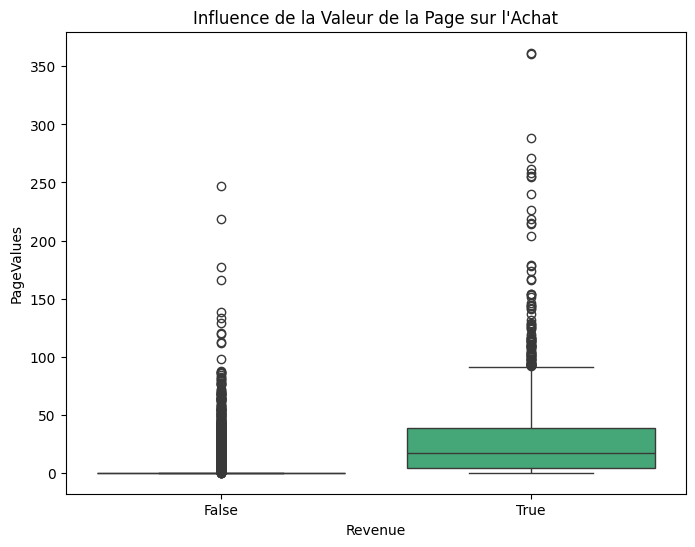

In [44]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Revenue', y='PageValues', data=df, palette='viridis')
plt.title("Influence de la Valeur de la Page sur l'Achat")
plt.show()

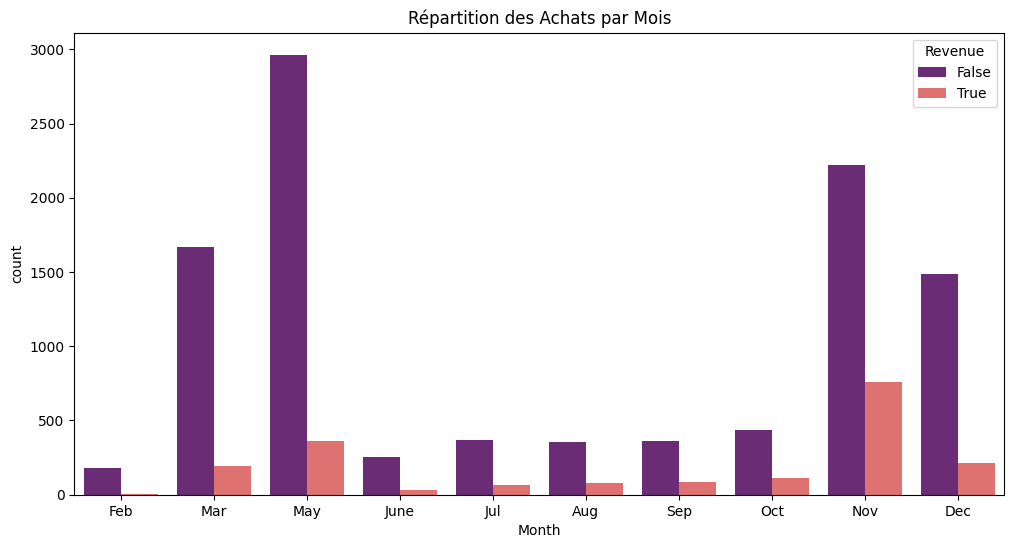

In [45]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Month', hue='Revenue', palette='magma', 
              order=['Feb', 'Mar', 'May', 'June', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.title("Répartition des Achats par Mois")
plt.show()

In [46]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Préparation des données (Features et Target)
# Nous séparons la colonne cible 'Revenue' du reste des données
X = df_final.drop('Revenue', axis=1) # Caractéristiques (variables explicatives)
y = df_final['Revenue'] # Cible (ce que le modèle doit prédire)

# 2. Division du dataset
# On sépare les données en deux ensembles : 80% pour l'entraînement et 20% pour le test
# random_state=42 assure la reproductibilité des résultats
# stratify=y permet de conserver la même proportion d'acheteurs dans les deux ensembles
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Affichage des dimensions des ensembles créés
print(f"Taille de l'entraînement : {X_train.shape[0]} échantillons")
print(f"Taille du test : {X_test.shape[0]} échantillons")

# 3. Configuration des modèles
# Initialisation de la Régression Logistique et du Random Forest
# class_weight='balanced' est utilisé pour compenser le faible nombre d'acheteurs (15%)
models = {
    "Regression Logistique": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
}

# 4. Boucle d'entraînement, prédiction et évaluation
for name, model in models.items():
    print(f"\n--- {name} ---")
    
    # Phase d'apprentissage : le modèle apprend les relations dans les données d'entraînement
    model.fit(X_train, y_train)
    
    # Phase de test : le modèle prédit si les visiteurs vont acheter sur l'ensemble de test
    y_pred = model.predict(X_test)
    
    # Évaluation des performances
    # Accuracy : pourcentage global de bonnes prédictions
    print("Score de précision (Accuracy) :", accuracy_score(y_test, y_pred))
    
    # Matrice de confusion : montre les vrais positifs, faux positifs, etc.
    print("\nMatrice de confusion :\n", confusion_matrix(y_test, y_pred))
    
    # Rapport détaillé : Précision, Rappel (Recall) et F1-score pour chaque classe
    print("\nRapport de classification :\n", classification_report(y_test, y_pred))

Taille de l'entraînement : 9764 échantillons
Taille du test : 2441 échantillons

--- Regression Logistique ---


c:\Users\aliin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Score de précision (Accuracy) : 0.8095043015157722

Matrice de confusion :
 [[1666  393]
 [  72  310]]

Rapport de classification :
               precision    recall  f1-score   support

           0       0.96      0.81      0.88      2059
           1       0.44      0.81      0.57       382

    accuracy                           0.81      2441
   macro avg       0.70      0.81      0.72      2441
weighted avg       0.88      0.81      0.83      2441


--- Random Forest ---
Score de précision (Accuracy) : 0.902498975829578

Matrice de confusion :
 [[1988   71]
 [ 167  215]]

Rapport de classification :
               precision    recall  f1-score   support

           0       0.92      0.97      0.94      2059
           1       0.75      0.56      0.64       382

    accuracy                           0.90      2441
   macro avg       0.84      0.76      0.79      2441
weighted avg       0.90      0.90      0.90      2441



In [47]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Séparation des caractéristiques (X) et de la cible (y)
X = df_final.drop('Revenue', axis=1) 
y = df_final['Revenue'] 

# 2. Division des données en ensemble d'entraînement et de test
# On utilise stratify=y pour maintenir la proportion de acheteurs/non-acheteurs
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Normalisation des données (Scaling)
# Liste des colonnes numériques identifiées dans l'analyse exploratoire
num_cols = ['Administrative', 'Administrative_Duration', 'Informational', 
            'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 
            'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']

scaler = StandardScaler()

# On crée des copies pour ne pas modifier les données originales
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# fit_transform calcule la moyenne/écart-type sur le TRAIN uniquement pour éviter la fuite de données
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
# On applique la même transformation au TEST
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

# 4. Définition des modèles
# On utilise 'balanced' pour gérer le déséquilibre des classes (85% vs 15%)
models = {
    "Régression Logistique (Scalée)": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Random Forest (Originale)": RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
}

# 5. Boucle d'entraînement et d'évaluation
for name, model in models.items():
    print(f"\n--- {name} ---")
    
    # Choix des données : Scalées pour la logistique, originales pour le Random Forest
    if "Scalée" in name:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    # Affichage des performances
    print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
    print("Rapport de classification :\n", classification_report(y_test, y_pred))


--- Régression Logistique (Scalée) ---
Accuracy : 0.8513
Rapport de classification :
               precision    recall  f1-score   support

           0       0.96      0.86      0.91      2059
           1       0.52      0.79      0.62       382

    accuracy                           0.85      2441
   macro avg       0.74      0.83      0.77      2441
weighted avg       0.89      0.85      0.86      2441


--- Random Forest (Originale) ---
Accuracy : 0.9025
Rapport de classification :
               precision    recall  f1-score   support

           0       0.92      0.97      0.94      2059
           1       0.75      0.56      0.64       382

    accuracy                           0.90      2441
   macro avg       0.84      0.76      0.79      2441
weighted avg       0.90      0.90      0.90      2441



C:\Users\aliin\AppData\Local\Temp\ipykernel_6952\3349870535.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=feature_names[indices], palette='magma')


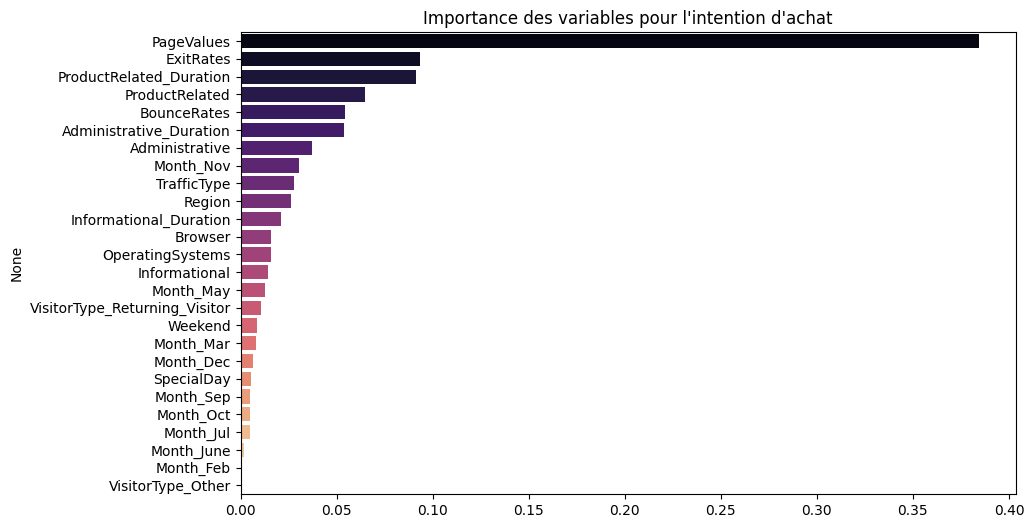

In [48]:


# Extraction de l'importance des variables du Random Forest
importances = models["Random Forest (Originale)"].feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1]

# Visualisation
plt.figure(figsize=(10, 6))
plt.title("Importance des variables pour l'intention d'achat")
sns.barplot(x=importances[indices], y=feature_names[indices], palette='magma')
plt.show()

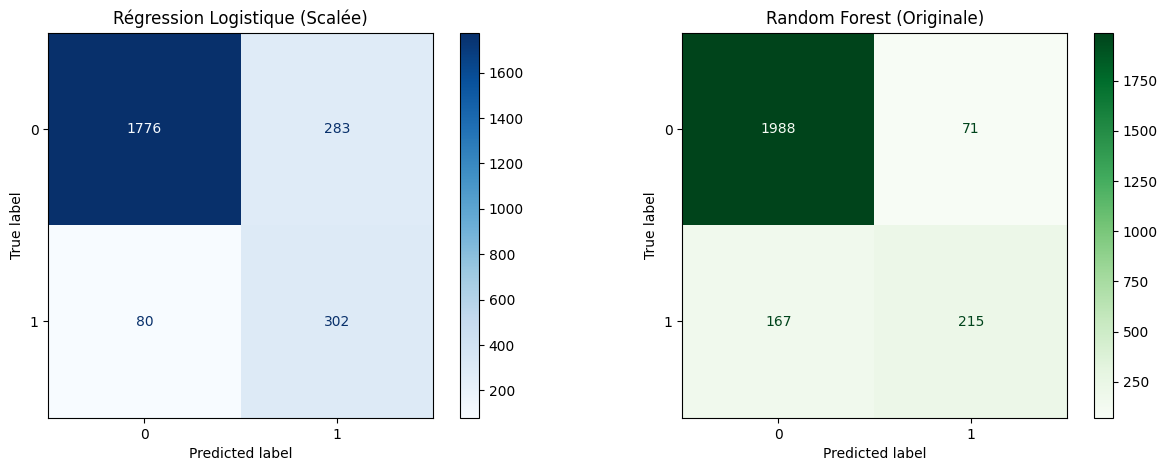

In [49]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Matrice pour la Régression Logistique
ConfusionMatrixDisplay.from_estimator(models["Régression Logistique (Scalée)"], 
                                       X_test_scaled, y_test, ax=ax[0], cmap='Blues')
ax[0].set_title("Régression Logistique (Scalée)")

# Matrice pour le Random Forest
ConfusionMatrixDisplay.from_estimator(models["Random Forest (Originale)"], 
                                       X_test, y_test, ax=ax[1], cmap='Greens')
ax[1].set_title("Random Forest (Originale)")

plt.show()